In [ ]:
from typing import Tuple
import numpy as np
from sklearn import datasets

from IPython.display import clear_output
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns

from typing import Any
from typing import Tuple
import torch
import torch.nn as nn
from torchvision import transforms
from torchvision.datasets import MNIST
from sklearn.metrics import accuracy_score
import random

sns.set(palette="Set2")
cm_bright = ListedColormap(["#FF3300", "#00CC66"])

---

Рассмотрим двухслойную полносвязную нейронную сеть, которая принимает на вход $x\in\mathbb{R}^d$ и возвращает $y\in\{0, 1\}$
$$y_\theta(x) = \sigma_2 \big( \sigma_1 \left( x^{\top} W_1 + b_1 \right) W_2 + b_2 \big),$$
где 
* $W_1 \in \mathbb{R}^{d \times h}, b_1 \in \mathbb{R}^{h}$ &mdash; параметры 1-го слоя,
* $W_2 \in \mathbb{R}^{h \times 1}, b_2 \in \mathbb{R}$ &mdash; параметры 2-го слоя,
* $\theta = (W_1, b_1, W_2, b_2)$ — все параметры нейросети,
* $\sigma_1(x) = \tanh x = \frac{e^{x} - e^{-x}}{e^{x} + e^{-x}}$ &mdash; гиперболический тангенс, функция активации 1-го слоя, применяется поэлементно,
* $\sigma_2(x) = \frac{1}{1 + e^{-x}}$ &mdash; логистическая сигмоида, функция активации 2-го слоя.

**1.** Нарисуйте схематически данную нейронную сеть. Сколько у нее обучаемых параметров?  
У этой нейросети $d \cdot h + h + h + 1 = d \cdot h + 2h + 1$ обучаемых параметров.

![сетка (1).png](<attachment:сетка (1).png>)

**2.** Дана обучающая выборка $X \in \mathbb{R}^{n \times d}$ — матрица входных данных и $Y \in \{0, 1\}^{n}$ — таргет. Нейронная сеть обучается по этой выборке, минимизируя заданную функцию $\mathscr{L}$, в данном случае рассмотрим кросс энтропию
$$\mathscr{L}(\theta) = -\sum_{i=1}^n \big( Y_i \log y_\theta(X_i) + (1-Y_i) \log \left(1-y_\theta(X_i)\right) \big).$$
Выпишите все необходимые производные для применения метода back propagation.

$\frac{\partial \mathscr{L}}{\partial y_\theta} = -\frac{Y}{y_\theta} + \frac{1 - Y}{1 - y_\theta} = \frac{y_\theta - Y}{y_\theta (1 - y_\theta)}$  
$\sigma_2'(x) = \sigma_2(x) (1 - \sigma_2(x))$  
$\sigma_1'(x) = 1 - \sigma_1^2(x)$

Введем обозначения (аналогичные лекции):  
$S_1 = X W_1 + b_1, \quad U_1 = \sigma_1(S_1)$  
$S_2 = U_1 W_2 + b_2, \quad U_2 = \sigma_2(S_2)$  

$\frac{\partial U_{2_{i}}}{\partial S_{2_{i}}} = {U_{2_{i}} (1 - U_{2_{i}})}$  
$\frac{\partial S_{2_{i}}}{\partial W_{2_{k}}} = U_{1_{ik}}$  
$\frac{\partial S_{2_{i}}}{\partial b_{2}} = 1$  
$\frac{\partial S_{2_{i}}}{\partial U_{1_{ik}}} = W_{2_{k}}$  
$\frac{\partial U_{1_{ik}}}{\partial S_{1_{ik}}} = {(1 - U_{1_{ik}}^2)}$  
$\frac{\partial S_{1_{ik}}}{\partial W_{1_{lk}}} = X_{il}$  
$\frac{\partial S_{1_{ik}}}{\partial b_{1_k}} = 1$  

**3.** Выпишите итоговый алгоритм обратного распространения ошибки для данной нейросети.

Просто последовательно считаю градиенты:  

$\frac{\partial \mathscr{L}}{\partial U_{2_{i}}} = \frac{U_{2_{i}} - Y_i}{U_{2_{i}} (1 - U_{2_{i}})}$  (для $U_2$)  

$\frac{\partial U_{2_{i}}}{\partial S_{2_{i}}} = {U_{2_{i}} (1 - U_{2_{i}})}$  
$\frac{\partial \mathscr{L}}{\partial S_{2_{i}}} = \frac{\partial \mathscr{L_i}}{\partial U_{2_{i}}} \cdot \frac{\partial U_{2_{i}}}{\partial S_{2_{i}}} = U_{2_{i}} - Y_i$   (для $S_2$)  

$S_{2_{i}} = \sum_{k=1}^{h} U_{1_{ik}} W_{2_{k}} + b_{2}$  

$\frac{\partial S_{2_{i}}}{\partial W_{2_{k}}} = U_{1_{ik}}$  
$\frac{\partial \mathscr{L}}{\partial W_{2_k}} = \sum_{i=1}^{n} \frac{\partial \mathscr{L}}{\partial S_{2_{i}}} \cdot \frac{\partial S_{2_{i}}}{\partial W_{2_{k}}} = \sum_{i=1}^{n} (U_{2_{i}} - Y_i) \cdot U_{1_{ik}}$ (для $W_2$)  

$\frac{\partial S_{2_{i}}}{\partial b_{2}} = 1$  
$\frac{\partial \mathscr{L}}{\partial b_{2}} = \sum_{i=1}^{n} \frac{\partial \mathscr{L}}{\partial S_{2_{i}}} \cdot \frac{\partial S_{2_{i}}}{\partial b_{2}} = \sum_{i=1}^{n} (U_{2_{i}} - Y_i)$ (для $b_2$)  

$\frac{\partial S_{2_{i}}}{\partial U_{1_{ik}}} = W_{2_{k}}$  
$\frac{\partial \mathscr{L}}{\partial U_{1_{ik}}} = \frac{\partial \mathscr{L}}{\partial S_{2_{i}}} \cdot \frac{\partial S_{2_{i}}}{\partial U_{1_{ik}}} = (U_{2_{i}} - Y_i) \cdot W_{2_{k}}$ (для $U_1$)  

$\frac{\partial U_{1_{ik}}}{\partial S_{1_{ik}}} = {(1 - U_{1_{ik}}^2)}$  
$\frac{\partial \mathscr{L}}{\partial S_{1_{ik}}} = \frac{\partial \mathscr{L_i}}{\partial U_{1_{ik}}} \cdot \frac{\partial U_{1_{ik}}}{\partial S_{1_{ik}}} = (U_{2_{i}} - Y_i) \cdot W_{2_{k}} \cdot (1 - U_{1_{ik}}^2)$   (для $S_1$) 

$S_{1_{ik}} = \sum_{l=1}^{d} X_{il} W_{1_{lk}} + b_{1_k}$  

$\frac{\partial S_{1_{ik}}}{\partial W_{1_{lk}}} = X_{il}$  
$\frac{\partial \mathscr{L}}{\partial W_{1_{lk}}} = \sum_{i=1}^{n} \frac{\partial \mathscr{L}}{\partial S_{1_{ik}}} \cdot \frac{\partial S_{1_{ik}}}{\partial W_{1_{lk}}} = \sum_{i=1}^{n} (U_{2_{i}} - Y_i) \cdot W_{2_{k}} \cdot (1 - U_{1_{ik}}^2) \cdot X_{il}$ (для $W_1$)  

$\frac{\partial S_{1_{ik}}}{\partial b_{1_k}} = 1$  
$\frac{\partial \mathscr{L}}{\partial b_{1_k}} = \sum_{i=1}^{n} \frac{\partial \mathscr{L}}{\partial S_{1_{ik}}} \cdot \frac{\partial S_{1_{ik}}}{\partial b_{1_k}} = \sum_{i=1}^{n} (U_{2_{i}} - Y_i) \cdot W_{2_{k}} \cdot (1 - U_{1_{ik}}^2)$ (для $b_1$)  

Сначала считается $\frac{\partial \mathscr{L}}{\partial U_{2_{i}}}$, потом с помощью вычесленного $\frac{\partial \mathscr{L}}{\partial S_{2_{i}}}$ и т.д. Предлагается идти ниже по списку из производных, которые написаны, используя при вычислениях вычесленные уже градиенты. 

Подсчет $\frac{\partial \mathscr{L}}{\partial U_{2_{i}}}$ занимает $O(1)$ (это просто математическое выражение).  
$\frac{\partial \mathscr{L}}{\partial S_{2_{i}}}$ - $O(1)$ (аналогично).  
Подсчет всех производных по $U_{2_{i}}$, $S_{2_{i}}$ - $O(n)$ ($n$ раз по константе).  
$\frac{\partial \mathscr{L}}{\partial W_{2_k}}$ - $O(n)$ (внутри сумма по n, где складывается уже вычисленное).  
$\frac{\partial \mathscr{L}}{\partial b_{2}}$ - $O(n)$ (аналогично).
Подсчет всех производных по параметрам второго слоя - $O(hn)$ ($h$ раз по $O(n)$).  
$\frac{\partial \mathscr{L}}{\partial U_{1_{ik}}}$, $\frac{\partial \mathscr{L}}{\partial S_{1_{ik}}}$ - $O(1)$ (просто математические выражения).  
Подсчет всех производных по $U_{1_{ik}}$, $S_{1_{ik}}$ - $O(nh)$ ($nh$ раз по константе).  
$\frac{\partial \mathscr{L}}{\partial W_{1_{lk}}}$, $\frac{\partial \mathscr{L}}{\partial b_{1_k}}$ - $O(n)$ (внутри сумма по n, где складывается уже вычисленное).  
Подсчет всех производных по параметрам второго слоя - $O(dn)$ ($d$ раз по $O(n)$).  
Общая сложность вычисления всех необходимых градиентов - $O(n(d+h))$.

Если считать градиенты в лоб, без использования метода обратного распространения ошибки, то сложность будет экспоненциально зависить от количества слоев. Но если переиспользовать производные по несколько раз, исользуя метод обратного распространения ошибки, можно сократить асимптотику до линейной, относительно $n$. Даже для двухслойной нейросети это очень существенно (квадрат и линия), а для каждого нового слоя разница будет всё больше.

---


**1.** На практике, чтобы сделать численные вычисления градиентов более стабильными, в качестве функции ошибки используют композицию бинарной кроссэнтропии и сигмоиды, передавая ей логиты в качестве аргументов, то есть выходы последнего линейного слоя. Выведите итоговую формулу градиента бинарной кроссэнтропии по выходу сети до применения сигмоиды.

$L = -\frac{1}{n} \sum_{i=1}^{n} \left[ y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i) \right]$  (я взяла усредненную функцию, потому что это логично, если дальше нужно будет реализовывать, по задаче не очень понятно, нужно брать усредненную или не усредненную функцию потерь).  
$\frac{\partial \mathscr{L}}{\partial y_\theta} = -\frac{1}{n}(\frac{Y}{y_\theta} + \frac{1 - Y}{1 - y_\theta}) = \frac{1}{n}(\frac{y_\theta - Y}{y_\theta (1 - y_\theta)})$ 

$\frac{\partial U_{2_{i}}}{\partial S_{2_{i}}} = \frac{1}{n} \cdot {U_{2_{i}} (1 - U_{2_{i}})}$  
$\frac{\partial \mathscr{L}}{\partial S_{2_{i}}} = \frac{1}{n} \cdot \frac{\partial \mathscr{L_i}}{\partial U_{2_{i}}} \cdot \frac{\partial U_{2_{i}}}{\partial S_{2_{i}}} = U_{2_{i}} - Y_i$   
(обозначения и функции из предыдущей задачи)

**2.** Реализуйте класс обучения нейронной сети из задачи 2 в sklearn-стиле, используя только библиотеку `numpy`. Используйте представленный ниже шаблон.

In [ ]:
# При реализации класса запрещено пользоваться ИИ-инструментами.

class TwoLayersNNClassifier:
    """Двухслойная нейронная сеть для задачи бинарной классификации.

    Параметры:
        input_size (int): Размер входного вектора.
        hidden_size (int): Количество нейронов в скрытом слое.
        learning_rate (float, optional): Скорость обучения (по умолчанию 0.01).
        n_epoch (int, optional): Количество эпох обучения (по умолчанию 100).
        weight_init_scale (float, optional): Масштаб для инициализации весов (по умолчанию 1).
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        learning_rate: float = 0.01,
        n_epoch: int = 100,
        weight_init_scale: float = 1,
    ):
        self.learning_rate = learning_rate
        self.n_epoch = n_epoch
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.weight_init_scale = weight_init_scale

        # Инициализация весов
        self._initialize_weights()

        # Инициализация градиентов
        self._zero_grad()

        # Для хранения истории потерь
        self.loss_history = []
        

    def _initialize_weights(self):
        """Инициализирует веса сети случайными значениями."""
        self.W1 = self._init_weight_matrix(self.input_size, self.hidden_size)
        self.b1 = self._init_weight_matrix(1, self.hidden_size)
        self.W2 = self._init_weight_matrix(self.hidden_size, 1)
        self.b2 = self._init_weight_matrix(1, 1)

    def _init_weight_matrix(self, rows: int, cols: int) -> np.ndarray:
        """Инициализирует матрицу весов случайными значениями.

        Параметры:
            rows (int): Количество строк.
            cols (int): Количество столбцов.

        Возвращает:
            np.ndarray: Матрица весов.
        """
        return (np.random.rand(rows, cols) * 2 - 1) * self.weight_init_scale

    @staticmethod
    def tanh_derivative(x: np.ndarray) -> np.ndarray:
        """Вычисляет производную функции гиперболического тангенса.

        Параметры:
            x (np.ndarray): Входной массив.

        Возвращает:
            np.ndarray: Производная функции tanh.
        """
        return 1 - np.tanh(x)**2

    @staticmethod
    def sigmoid(x: np.ndarray, scale: int = 1000) -> np.ndarray:
        """Вычисляет логистическую сигмоиду.

        Параметры:
            x (np.ndarray): Входной массив.
            scale (int, optional): Максимальное абсолютное значение для ограничения (по умолчанию 1000).

        Возвращает:
            np.ndarray: Значения сигмоиды.
        """
        x = np.clip(x, -scale, scale)  # Ограничиваем значения
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def binary_crossentropy(y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """Вычисляет значение бинарной кросс-энтропии.

        Параметры:
            y_pred (np.ndarray): Предсказанные значения (вероятности).
            y_true (np.ndarray): Истинные значения (0 или 1).

        Возвращает:
            float: Значение бинарной кросс-энтропии.
        """

        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss

    @staticmethod
    def output_gradient(logits: np.ndarray, y: np.ndarray) -> np.ndarray:
        """Вычисляет градиент по выходу сети до применения сигмоиды.

        Параметры:
            logits (np.ndarray): Предсказанные значения.
            y (np.ndarray): Истинные значения.

        Возвращает:
            np.ndarray: Градиент по выходу до применения сигмоиды.
        """

        # Вычислите градиент по выходу сети до применения сигмоиды.
        # Спойлер: получится очень простая формула
        return (logits - y) / len(y)

    def _forward(self, X: np.ndarray) -> np.ndarray:
        """Выполняет прямой проход по сети.

        Параметры:
            X (np.ndarray): Входные данные.

        Возвращает:
            np.ndarray: Выход сети (вероятности).
        """
        self.S1 = X @ self.W1 + self.b1
        self.U1 = np.tanh(self.S1)
        self.S2 = self.U1 @ self.W2 + self.b2 
        self.U2 = self.sigmoid(self.S2)
        
        return self.U2

    def _backward(self, X: np.ndarray, y: np.ndarray, y_pred: np.ndarray):
        """Выполняет обратный проход (backpropagation), накапливает градиенты.

        Параметры:
            X (np.ndarray): Входные данные.
            y (np.ndarray): Истинные значения.
        """

        # Градиент по выходу до применения сигмоиды
        ds2 = self.output_gradient(y_pred, y)

        # Градиент по параметрам 2-го слоя
        self.dW2 = (self.U1.T @ ds2)
        self.db2 = np.sum(ds2, axis=0, keepdims=True)

        # Градиент по выходу скрытого слоя
        du1 = ds2 @ self.W2.T
        ds1 = du1 * (1 - self.U1 ** 2)

        # Градиент по параметрам 1-го слоя
        self.dW1 = (X.T @ ds1)
        self.db1 = np.sum(ds1, axis=0, keepdims=True)

    def _step(self):
        """Обновляет веса сети на основе вычисленных градиентов."""

        self.W2 -= self.learning_rate * self.dW2
        self.b2 -= self.learning_rate * self.db2
        self.W1 -= self.learning_rate * self.dW1
        self.b1 -= self.learning_rate * self.db1

    def _zero_grad(self):
        """Обнуляет градиенты перед следующим шагом обучения."""
        self.dW1 = np.zeros_like(self.W1)
        self.db1 = np.zeros_like(self.b1)
        self.dW2 = np.zeros_like(self.W2)
        self.db2 = np.zeros_like(self.b2)

    def _show_progress(self, epoch: int, plot_freq: int):
        """Выводит прогресс обучения на каждой итерации.

        Параметры:
            epoch (int): Номер текущей эпохи.
            plot_freq (int): Частота отрисовки графика.
        """
        info_text = f"Эпоха {epoch + 1}/{self.n_epoch}, Лосс: {self.loss_history[-1]:.4f}"

        if plot_freq == 0:
            clear_output(wait=True)  # Очистка вывода
            print(info_text)

        elif (epoch + 1) % plot_freq == 0:
            clear_output(wait=True)  # Очистка вывода
            plt.figure(figsize=(8, 4))
            plt.plot(self.loss_history)
            plt.xlabel("Номер эпохи")
            plt.ylabel("Лосс")
            plt.title(info_text)
            plt.show()

    def fit(self, X: np.ndarray, y: np.ndarray, verbose: bool = True, plot_freq: int = 0):
        """Обучает модель на предоставленных данных.

        Параметры:
            X (np.ndarray): Входные данные.
            y (np.ndarray): Истинные значения (0 или 1).
            verbose (bool, optional): Если True, выводит прогресс обучения (по умолчанию True).
            plot_freq (int, optional): Частота отрисовки графика.
                    Если 0, график не рисуется (по умолчанию 0).
        """
        y = y[:, None]
        self.loss_history = []  # Очистка истории потерь перед обучением

        for epoch in range(self.n_epoch):

            # Прямой проход по сети
            y_pred = self._forward(X)
            loss = self.binary_crossentropy(y_pred, y)
            self.loss_history.append(loss)  # Сохраняем значение потерь

            self._backward(X, y, y_pred)
            self._step()
            self._zero_grad()

            if verbose:
                self._show_progress(epoch, plot_freq)
                
        return self.loss_history

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Предсказывает классы для входных данных.

        Параметры:
            X (np.ndarray): Входные данные.

        Возвращает:
            np.ndarray: Предсказанные классы (0 или 1).
        """
        y_pred = self._forward(X)
        return (y_pred > 0.5).astype(int)  # Порог 0.5 для бинарной классификации

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности принадлежности к классам 0 и 1.

        Параметры:
        X (np.ndarray): Входные данные.

        Возвращает:
        np.ndarray: Матрица вероятностей формы (n, 2), где n — количество объектов.
                   Первый столбец — вероятность класса 0, второй — класса 1.
        """

        y_pred = self._forward(X)
        prob_class_1 = y_pred  # Вероятность класса 1
        prob_class_0 = 1 - y_pred  # Вероятность класса 0
        return np.hstack((prob_class_0, prob_class_1))  # Объединяем в матрицу (n, 2)
    

Сгенерируем искусственные данные

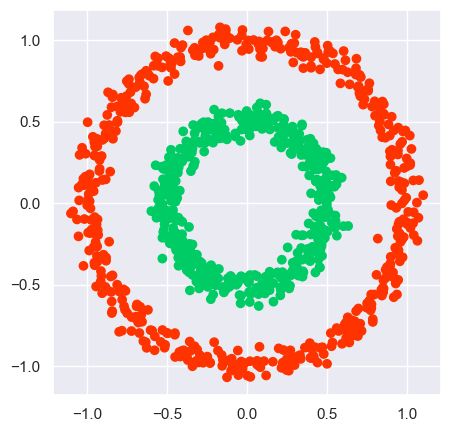

In [483]:
# Генерация данных
n_samples = 1024
X, y = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)

# Визуализация данных
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright)
plt.show()

Обучите реализованную ранее нейросеть решать задачу классификации на основе этой выборки.

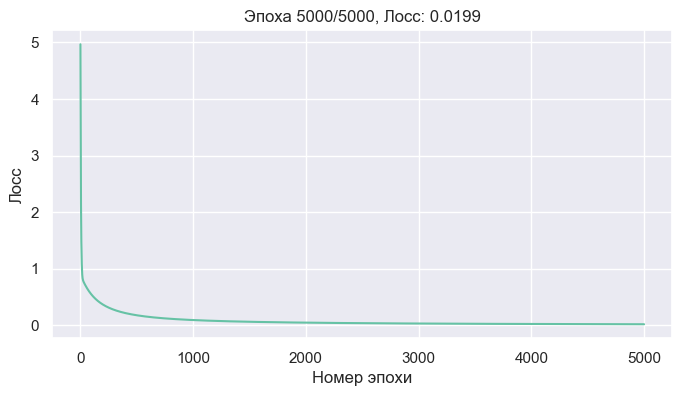

In [484]:
input_size = 2
hidden_size = 700
n_epoch = 5000

model = TwoLayersNNClassifier(input_size=input_size, hidden_size=hidden_size, n_epoch=n_epoch)
loss_history = model.fit(X, y,  verbose=True, plot_freq=50)

In [485]:
loss_history[-1] # лосс в самом конце

0.019932538767181675

In [486]:
x_min, x_max = -1.5, 1.5
y_min, y_max = -1.5, 1.5

xn, yn = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xn.ravel(), yn.ravel()]

y_prob = model.predict_proba(grid_points)
prob_class_1 = y_prob[:, 1].reshape(xn.shape)

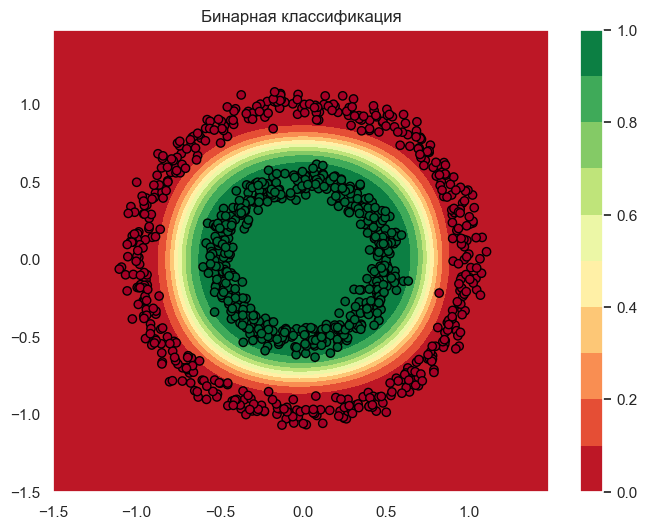

In [487]:
plt.figure(figsize=(8, 6))

plt.contourf(xn, yn, prob_class_1, levels=np.linspace(0, 1, 11), cmap='RdYlGn')
plt.colorbar()

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', edgecolors='k', marker='o')
plt.title('Бинарная классификация')
plt.show()

Немного увеличим разброс данных

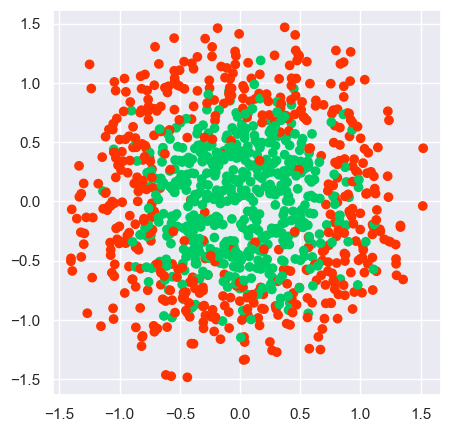

In [488]:
# Генерация данных
n_samples = 1024
X, y = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.25)

# Визуализация данных
plt.figure(figsize=(5, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap=cm_bright)
plt.show()

Повторите те же действия с новыми данными.

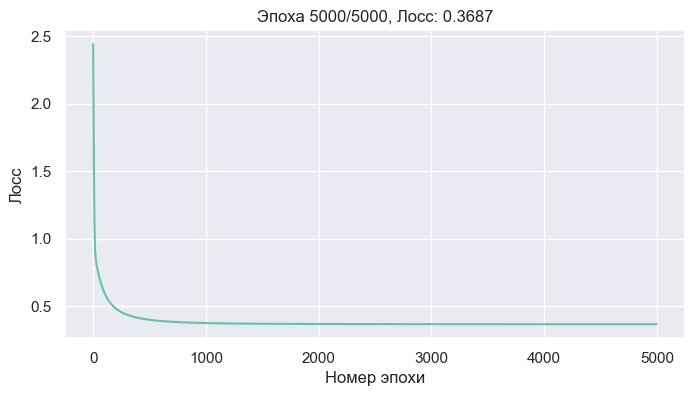

In [489]:
input_size = 2
hidden_size = 700
n_epoch = 5000

model = TwoLayersNNClassifier(input_size=input_size, hidden_size=hidden_size, n_epoch=n_epoch)
loss_history = model.fit(X, y, verbose=True, plot_freq=50)

In [490]:
loss_history[-1] # лосс в самом конце

0.36867325206313983

In [491]:
x_min, x_max = -2, 2
y_min, y_max = -2, 2

xn, yn = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
grid_points = np.c_[xn.ravel(), yn.ravel()]

y_prob = model.predict_proba(grid_points)
prob_class_1 = y_prob[:, 1].reshape(xn.shape)

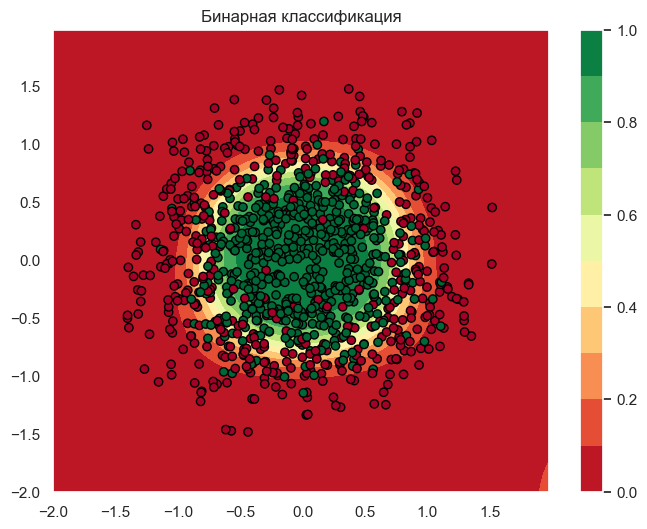

In [492]:
plt.figure(figsize=(8, 6))

plt.contourf(xn, yn, prob_class_1, levels=np.linspace(0, 1, 11), cmap='RdYlGn')
plt.colorbar()

plt.scatter(X[:, 0], X[:, 1], c=y, cmap='RdYlGn', edgecolors='k', marker='o')
plt.title('Бинарная классификация')
plt.show()

В первом случае классы довольно сильно разделены, поэтому (видно по графику и понятно по лоссу) классификация проходит достаточно хорошо. Я точно не проверяла, но визуально о графику нет ни одной ошибки. Во втором хорошо классифицируются точки близкие к центру (зеленые) и далекие от центра (красные). Для точек в середине тяжело делать предсказания, тк вероятности обоих классов ~0.5, значит принадлежность к одному из классов выдается почти рандомно, поэтому много ошибок. И много ошибок для точек, которые залезли на "чужую территорию". В целом из-за плохого разделения классов модель справляется не особо хорошо.

**4.** Теперь давайте применим нашу нейронную сеть к данным MNIST.

Поскольку наша сеть была разработана для бинарной классификации, мы будем рассматривать изображения, на которых представлены только две цифры: `0` и `1`. Возьмите по 1000 изображений каждого символа и преобразуйте их в векторы. Также выделите изображения из тестовой выборки, соответствующие этим цифрам.

In [493]:
def load_mnist(
    train_size: int = 10000, target_size: int = 14
) -> Tuple[torch.Tensor, torch.Tensor, torch.Tensor, torch.Tensor]:
    """Загружает и подготавливает данные MNIST для обучения и тестирования.

    Параметры:
    train_size (int): Количество обучаемых данных. По умолчанию 6000.
    target_size (int): Размер, до которого уменьшаются изображения. По умолчанию 14.

    Возвращает:
    train_images (torch.Tensor): Тензор с изображениями для обучения.
    train_labels (torch.Tensor): Тензор с метками для обучения.
    test_images (torch.Tensor): Тензор с изображениями для тестирования.
    test_labels (torch.Tensor): Тензор с метками для тестирования.

    Данные загружаются из набора MNIST, нормализуются, уменьшаются в
    размере и преобразуются в векторы. Для обучения используется только
    часть (train_fraction) от исходного набора данных.
    """

    PIXEL_MAX_VALUE = 255.0  # Для нормализации значений пикселей

    # Создаем преобразование для данных: конвертируем изображения в тензоры PyTorch
    transform = transforms.Compose(
        [
            # Преобразует изображение в тензор и нормализует значения в диапазоне [0, 1]
            transforms.ToTensor(),
        ]
    )

    # Загружаем обучающий и тестовый наборы данных MNIST
    train_dataset = MNIST(root="./data", train=True, transform=transform, download=True)
    test_dataset = MNIST(root="./data", train=False, transform=transform, download=True)

    # Выбираем часть обучающего набора данных
    train_indices = np.random.choice(len(train_dataset), train_size, replace=False)

    # Преобразуем изображения в тензоры и нормализуем их, деля на PIXEL_MAX_VALUE
    train_images = train_dataset.data[train_indices].unsqueeze(1).float() / PIXEL_MAX_VALUE
    test_images = test_dataset.data.unsqueeze(1).float() / PIXEL_MAX_VALUE

    # Уменьшаем размер изображений до target_size x target_size с использованием билинейной интерполяции
    train_images = torch.nn.functional.interpolate(
        train_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )
    test_images = torch.nn.functional.interpolate(
        test_images, size=(target_size, target_size), mode="bilinear", align_corners=False
    )

    # Преобразуем изображения в векторы (разворачиваем в одномерные массивы)
    train_images = train_images.view(train_size, -1)
    test_images = test_images.view(len(test_dataset), -1)

    # Получаем метки для выбранных обучающих и всех тестовых данных
    train_labels = train_dataset.targets[train_indices]
    test_labels = test_dataset.targets

    return train_images, train_labels, test_images, test_labels

In [494]:
train_images, train_labels, test_images, test_labels = load_mnist()

train_images_numpy = train_images.numpy()
train_labels_numpy = train_labels.numpy()
test_images_numpy = test_images.numpy()
test_labels_numpy = test_labels.numpy() 

train_indices_0_1 = np.where((train_labels == 0) | (train_labels == 1))[0]
test_indices_0_1 = np.where((test_labels == 0) | (test_labels == 1))[0]

train_images_0_1 = train_images[train_indices_0_1]
train_labels_0_1 = train_labels[train_indices_0_1]
test_images_0_1 = test_images[test_indices_0_1]
test_labels_0_1 = test_labels[test_indices_0_1]

train_images_0_1 = np.concatenate([train_images_0_1[train_labels_0_1 == 0][:1000], train_images_0_1[train_labels_0_1 == 1][:1000]])
train_labels_0_1 = np.concatenate([train_labels_0_1[train_labels_0_1 == 0][:1000], train_labels_0_1[train_labels_0_1 == 1][:1000]])
test_images_0_1 = np.concatenate([test_images_0_1[test_labels_0_1 == 0][:1000], test_images_0_1[test_labels_0_1 == 1][:1000]])
test_labels_0_1 = np.concatenate([test_labels_0_1[test_labels_0_1 == 0][:1000], test_labels_0_1[test_labels_0_1 == 1][:1000]])

In [495]:
train_images_0_1 = train_images_0_1.reshape(train_images_0_1.shape[0], -1)
test_images_0_1 = test_images_0_1.reshape(test_images_0_1.shape[0], -1)

Обучите реализованную ранее нейронную сеть к этим данным.


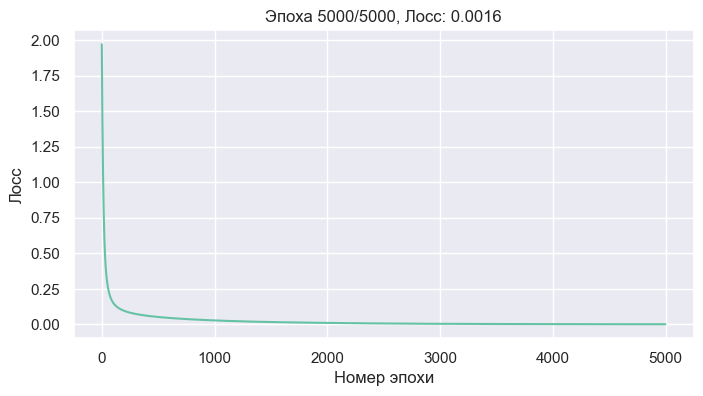

In [496]:
model = TwoLayersNNClassifier(input_size=train_images_0_1.shape[1], hidden_size=300, n_epoch=5000)

loss_history = model.fit(train_images_0_1, train_labels_0_1, verbose=True, plot_freq=50)

In [497]:
y_pred = model.predict(test_images_0_1)
accuracy = accuracy_score(test_labels_0_1, y_pred)
accuracy #точность

0.9974747474747475

Для разделения 0 и 1 модель работает достаточно хорошо (на мой взгляд 99,75% достаточная точность для бинарной классификации). 

Данная можель работает очень хорошо для классификации 0 и 1. Не очень понятно, в целом есть ли от этого глубокий практический смысл (хочется, всё таки, все цифры распознавать, не только две), а такая модель не умеет выдавать небинарный ответ. Судя по графику lossа, можно было остановить обучение гораздо раньше, настолько сильно ее учить не имело смысла.

---

Рассмотрим глубокую нейронную сеть, которая
* принимает на вход $x\in\mathbb{R}^d$,
* возвращает $y\in\{0, 1\}$,
* содержит $99$ полносвязных слоев (`Linear`) с функцией активации $\tanh$, за исключением последнего слоя,
* последний слой использует функцию активации логистическая сигмоида.

В качестве лосса $\mathscr{L}(\theta)$ возьмем кросс-энтропию.

**1.** Распишите градиент лосса по весам первого слоя $W_1$. Какова сложность этой операции?

Я ввожу обозначения, провожу операции абсолютно аналогично задаче 2, поэтому я не поясняю происходящее.  

$\quad \frac{d\mathscr{L}}{dS_{99}} = U_{99} - Y$
$\frac{d\mathscr{L}}{dW_{99}} = U_{98}^T \cdot dS_{99}$  
$\quad \frac{d\mathscr{L}}{dU_{98}} = dS_{99} \cdot W_{99}^T$  
$\quad \frac{d\mathscr{L}}{dS_{98}} = dU_{98} \cdot (1 - U_{98}^2)$  
$\quad \cdot\cdot\cdot $  
$\quad \frac{d\mathscr{L}}{dU_i} = dS_{i+1} \cdot W_{i+1}^T$  
$\quad \frac{d\mathscr{L}}{dS_i}= dU_i \cdot (1 - U_i^2)$  
$\quad \cdot\cdot\cdot $  
$\quad \frac{d\mathscr{L}}{dU_1} = dS_{2} \cdot W_{2}^T$  
$\quad \frac{d\mathscr{L}}{dS_1}= dU_1 \cdot (1 - U_1^2)$  
$\frac{d\mathscr{L}}{dW_1} = X^T \cdot dS_1$  

Сложность подсчета этого градиента будет $O(99h\cdot n)$, тоже так же оценивается как в задаче 2.

Нарисуйте график функции активации и ее производной.

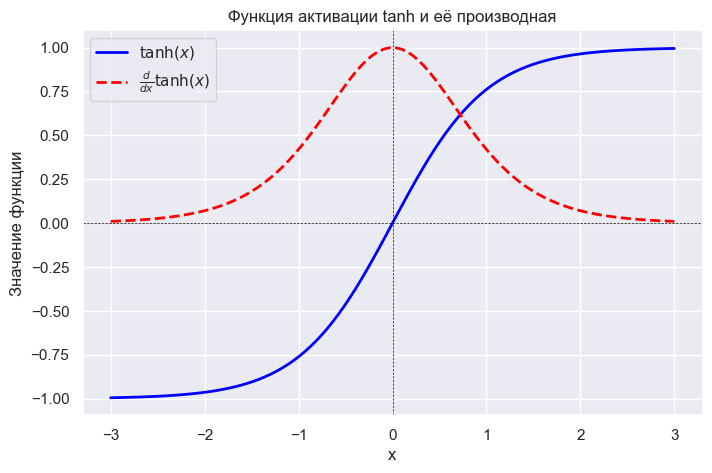

In [498]:
x = np.linspace(-3, 3, 100)
tanh_x = np.tanh(x)
tanh_derivative = 1 - np.tanh(x) ** 2

plt.figure(figsize=(8, 5))
plt.plot(x, tanh_x, label=r'$\tanh(x)$', color='b', linewidth=2)
plt.plot(x, tanh_derivative, label=r'$\frac{d}{dx} \tanh(x)$', color='r', linestyle='--', linewidth=2)

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
plt.legend()
plt.xlabel("x")
plt.ylabel("Значение функции")
plt.title("Функция активации tanh и её производная")
plt.grid(True)
plt.show()

$tanh$ принимает значения от $-1$ до $1$, она нечетная, в $0$ значение $0$, при уходе на $\pm \infty$ стремится к $\pm 1$.  
$tanh'$ принимает значения от $0$ до $1$, она четная, в $0$ значение $1$, при стремлении к $\pm \infty$ стремится к $0$.
Если значения получаются слишом большими, то $tanh'$ оказывается почти нулем, а при возведении в 99 (или какю-то меньше, но всё равно, скорее всего, в достаточно большую) степень можно считать, что это и есть ноль. Тогда веса первого слоя просто перестанут обновляться.

**2.** Реализуйте эту нейросеть на **PyTorch**.

In [499]:
class DeepNN(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers = 99):
        super(DeepNN, self).__init__()
        self.num_layers = num_layers
        
        self.layers = nn.ModuleList()
        
        self.layers.append(nn.Linear(input_size, hidden_size))
        for _ in range(num_layers - 2):
            self.layers.append(nn.Linear(hidden_size, hidden_size))

        self.layers.append(nn.Linear(hidden_size, 2))
    
    def forward(self, x):
        for i in range(self.num_layers - 1):
            x = torch.tanh(self.layers[i](x))
        x = torch.sigmoid(self.layers[-1](x)) 
        return x

In [500]:
input_size = 196
hidden_size = 128

model = DeepNN(input_size, hidden_size)

Аналогично задаче 3 попробуйте обучить эту нейросеть для классификации изображений с цифрами 0 и 1 из датасета MNIST. Скорее всего весь датасет не поместится в память, поэтому предлагается использовать случайную подвыборку (батч) размера 32 на каждом шаге обучения.

In [501]:
train_images, train_labels, test_images, test_labels = load_mnist()

train_indices_0_1 = (train_labels == 0) | (train_labels == 1)
test_indices_0_1 = (test_labels == 0) | (test_labels == 1)

train_images_0_1 = train_images[train_indices_0_1]
train_labels_0_1 = train_labels[train_indices_0_1]
test_images_0_1 = test_images[test_indices_0_1]
test_labels_0_1 = test_labels[test_indices_0_1]

train_images_0_1 = torch.cat([train_images_0_1[train_labels_0_1 == 0][:1000], train_images_0_1[train_labels_0_1 == 1][:1000]])
train_labels_0_1 = torch.cat([train_labels_0_1[train_labels_0_1 == 0][:1000], train_labels_0_1[train_labels_0_1 == 1][:1000]])
test_images_0_1 = torch.cat([test_images_0_1[test_labels_0_1 == 0][:1000], test_images_0_1[test_labels_0_1 == 1][:1000]])
test_labels_0_1 = torch.cat([test_labels_0_1[test_labels_0_1 == 0][:1000], test_labels_0_1[test_labels_0_1 == 1][:1000]])

In [ ]:
def step(model, optimizer, criterion, x_batch, y_batch, history):
    model.train()
    optimizer.zero_grad()

    # Прямой проход
    outputs = model(x_batch)
    loss = criterion(outputs, y_batch)

    # Обратный проход
    loss.backward()

    # Сохраняем значения градиентов
    grad_info = {}
    for name, param in model.named_parameters():
        if param.grad is not None:
            grad_info[name] = param.grad.detach().cpu().numpy()

    optimizer.step()

    # Accuracy
    with torch.no_grad():
        _, predicted = torch.max(outputs.data, 1)
        labels = y_batch  # просто используем y_batch напрямую
        correct = (predicted == labels).sum().item()
        accuracy = correct / y_batch.size(0)

    # Логируем в history
    history.setdefault("loss", []).append(loss.item())
    history.setdefault("accuracy", []).append(accuracy)
    history.setdefault("gradients", []).append(grad_info)

    return loss.item(), accuracy

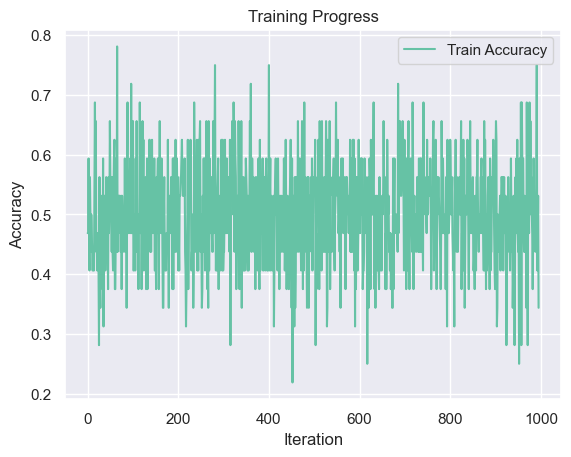

In [506]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-5)
criterion = nn.CrossEntropyLoss()
history = {}

for iteration in range(1000):
    indices = random.sample(range(len(train_images_0_1)), 32)
    batch_images = train_images_0_1[indices]
    batch_labels = train_labels_0_1[indices]

    loss, acc = step(model, optimizer, criterion, batch_images, batch_labels, history)


    if iteration % 5 == 0:
        clear_output(wait=True)
        plt.plot(history["accuracy"], label="Train Accuracy")
        plt.xlabel("Iteration")
        plt.ylabel("Accuracy")
        plt.title("Training Progress")
        plt.legend()
        plt.show()


Я очень-очень долго пыталась пообрать какие-то подходящие параметры (от $10^-50$ до $1$) или найти ошибку в том, что делаю, но я на 99,9% уверена, что всё правильно и какаим бы не брать шаг ничего глобально не поменяется. Мне кажется, так и должно быть.

Постройте график зависимости среднего и максимального абсолютного значения градиента по весам для каждого слоя от номера слоя.

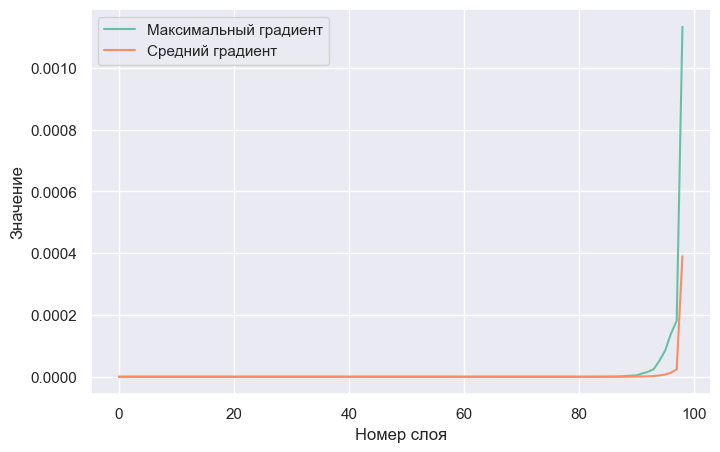

In [507]:
last_grads = history["gradients"][-1]
num_layers = len(model.layers)

mean_grads = np.zeros(num_layers)
max_grads = np.zeros(num_layers)

for i in range(num_layers):
    layer_name = f"layers.{i}.weight"
    if layer_name in last_grads:
        abs_grad = np.abs(last_grads[layer_name])
        mean_grads[i] = abs_grad.mean()
        max_grads[i] = abs_grad.max()
        
    
plt.figure(figsize=(8, 5))
plt.plot(range(num_layers), max_grads, label="Максимальный градиент")
plt.plot(range(num_layers), mean_grads, label="Средний градиент", marker=None)
plt.xlabel("Номер слоя")
plt.ylabel("Значение")
plt.legend()
plt.show()

Нарисую на логарифмической шкале.

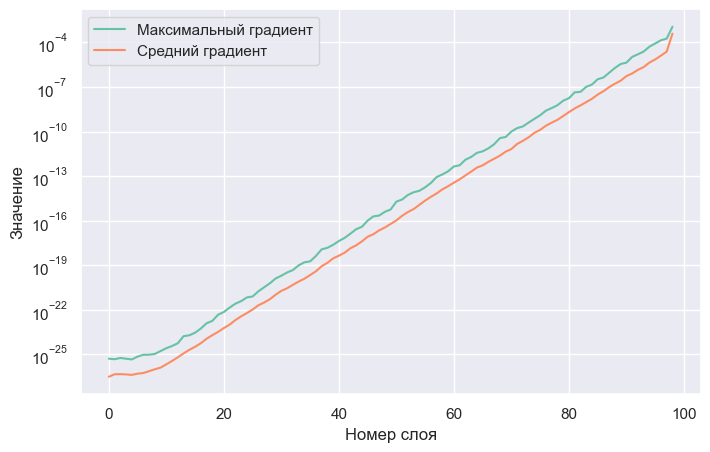

In [508]:
plt.figure(figsize=(8, 5))
plt.plot(range(num_layers), max_grads, label="Максимальный градиент")
plt.plot(range(num_layers), mean_grads, label="Средний градиент", marker=None)
plt.xlabel("Номер слоя")
plt.ylabel("Значение")
plt.yscale("log")
plt.legend()
plt.show()

Можно считать, что модель не обучается. Обычно это связано с плохим выбором шага, но я перепробовала довольно много, и особой разницы не было. По графикам градиентов видно, что они растут примерно экспоненциально. Поэтому точность меняется скачкообразно (может в среднем по больнице она возрастает, но по графику этого нельзя сказать). Мне кажется, что с этой моделью ничего нельзя сделать, только менять функции активации или параметры.

In [509]:
# я неправильно прочитала задание и реализоала аналогично предыдущей задаче, но жалко удалять (это не надо смотреть)

class TwoLayersNNClassifier:
    """99 нейронная сеть для задачи бинарной классификации.

    Параметры:
        input_size (int): Размер входного вектора.
        hidden_size (int): Количество нейронов в скрытом слое.
        learning_rate (float, optional): Скорость обучения (по умолчанию 0.01).
        n_epoch (int, optional): Количество эпох обучения (по умолчанию 100).
        weight_init_scale (float, optional): Масштаб для инициализации весов (по умолчанию 1).
    """

    def __init__(
        self,
        input_size: int,
        hidden_size: int,
        learning_rate: float = 0.01,
        n_epoch: int = 100,
        weight_init_scale: float = 1,
    ):
        self.learning_rate = learning_rate
        self.n_epoch = n_epoch
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.weight_init_scale = weight_init_scale

        # Инициализация весов
        self._initialize_weights()

        # Инициализация градиентов
        self._zero_grad()

        # Для хранения истории потерь
        self.loss_history = []
        

    def _initialize_weights(self):
        """Инициализирует веса сети случайными значениями."""
        self.W = []
        self.b = []
        self.W.append(self._init_weight_matrix(self.input_size, self.hidden_size))
        self.b.append(self._init_weight_matrix(1, self.hidden_size))
        for i in range (97):
            self.W.append(self._init_weight_matrix(self.hidden_size, self.hidden_size))
            self.b.append(self._init_weight_matrix(1, self.hidden_size))
        self.W.append(self._init_weight_matrix(self.hidden_size, 1))
        self.b.append(self._init_weight_matrix(1, 1))

    def _init_weight_matrix(self, rows: int, cols: int) -> np.ndarray:
        """Инициализирует матрицу весов случайными значениями.

        Параметры:
            rows (int): Количество строк.
            cols (int): Количество столбцов.

        Возвращает:
            np.ndarray: Матрица весов.
        """
        return (np.random.rand(rows, cols) * 2 - 1) * self.weight_init_scale

    @staticmethod
    def tanh_derivative(x: np.ndarray) -> np.ndarray:
        """Вычисляет производную функции гиперболического тангенса.

        Параметры:
            x (np.ndarray): Входной массив.

        Возвращает:
            np.ndarray: Производная функции tanh.
        """
        return 1 - np.tanh(x)**2

    @staticmethod
    def sigmoid(x: np.ndarray, scale: int = 1000) -> np.ndarray:
        """Вычисляет логистическую сигмоиду.

        Параметры:
            x (np.ndarray): Входной массив.
            scale (int, optional): Максимальное абсолютное значение для ограничения (по умолчанию 1000).

        Возвращает:
            np.ndarray: Значения сигмоиды.
        """
        x = np.clip(x, -scale, scale)  # Ограничиваем значения
        return 1 / (1 + np.exp(-x))

    @staticmethod
    def binary_crossentropy(y_pred: np.ndarray, y_true: np.ndarray) -> float:
        """Вычисляет значение бинарной кросс-энтропии.

        Параметры:
            y_pred (np.ndarray): Предсказанные значения (вероятности).
            y_true (np.ndarray): Истинные значения (0 или 1).

        Возвращает:
            float: Значение бинарной кросс-энтропии.
        """

        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss

    @staticmethod
    def output_gradient(logits: np.ndarray, y: np.ndarray) -> np.ndarray:
        """Вычисляет градиент по выходу сети до применения сигмоиды.

        Параметры:
            logits (np.ndarray): Предсказанные значения.
            y (np.ndarray): Истинные значения.

        Возвращает:
            np.ndarray: Градиент по выходу до применения сигмоиды.
        """

        # Вычислите градиент по выходу сети до применения сигмоиды.
        # Спойлер: получится очень простая формула
        return (logits - y) / len(y)

    def _forward(self, X: np.ndarray) -> np.ndarray:
        """Выполняет прямой проход по сети.

        Параметры:
            X (np.ndarray): Входные данные.

        Возвращает:
            np.ndarray: Выход сети (вероятности).
        """
        self.S = []
        self.U = []
        self.S.append(X @ self.W[0] + self.b[0])
        self.U.append(np.tanh(self.S1))
        for i in range (97):
            self.S.append(self.U[i-1] @ self.W[i] + self.b[i])
            self.U.append(np.tanh(self.S1))
        self.append(self.U[97] @ self.W[98] + self.b[98])
        self.append(self.sigmoid(self.S[98]))
        
        return self.U[98]

    def _backward(self, X: np.ndarray, y: np.ndarray, y_pred: np.ndarray):
        """Выполняет обратный проход (backpropagation), накапливает градиенты.

        Параметры:
            X (np.ndarray): Входные данные.
            y (np.ndarray): Истинные значения.
        """
        ds = [0] * 99
        du = [0] * 99

        # Градиент по выходу до применения сигмоиды
        self.ds[98] = self.output_gradient(y_pred, y)


        for i in range (98, 0, -1):
            self.dw[i] = (self.U[i-1].T @ ds[i])
            self.db[i] = np.sum(ds[i], axis=0, keepdims=True)

            du[i-1] = ds[i] @ self.W[i].T
            ds[i-1] = du[i-1] * (1 - self.U[i-1] ** 2)

        # Градиент по параметрам 1-го слоя
        self.dW1 = (X.T @ ds[0])
        self.db1 = np.sum(ds[0], axis=0, keepdims=True)

    def _step(self):
        """Обновляет веса сети на основе вычисленных градиентов."""

        for i in range (99):
            self.W[i] -= self.learning_rate * self.dW[i]
            self.b[i] -= self.learning_rate * self.db[i]

    def _zero_grad(self):
        """Обнуляет градиенты перед следующим шагом обучения."""
        for i in range (99):
            self.dW[i] = np.zeros_like(self.W[i])
            self.db[i] = np.zeros_like(self.b[i])
       
    def _show_progress(self, epoch: int, plot_freq: int):
        """Выводит прогресс обучения на каждой итерации.

        Параметры:
            epoch (int): Номер текущей эпохи.
            plot_freq (int): Частота отрисовки графика.
        """
        info_text = f"Эпоха {epoch + 1}/{self.n_epoch}, Лосс: {self.loss_history[-1]:.4f}"

        if plot_freq == 0:
            clear_output(wait=True)  # Очистка вывода
            print(info_text)

        elif (epoch + 1) % plot_freq == 0:
            clear_output(wait=True)  # Очистка вывода
            plt.figure(figsize=(8, 4))
            plt.plot(self.loss_history)
            plt.xlabel("Номер эпохи")
            plt.ylabel("Лосс")
            plt.title(info_text)
            plt.show()

    def fit(self, X: np.ndarray, y: np.ndarray, verbose: bool = True, plot_freq: int = 0):
        """Обучает модель на предоставленных данных.

        Параметры:
            X (np.ndarray): Входные данные.
            y (np.ndarray): Истинные значения (0 или 1).
            verbose (bool, optional): Если True, выводит прогресс обучения (по умолчанию True).
            plot_freq (int, optional): Частота отрисовки графика.
                    Если 0, график не рисуется (по умолчанию 0).
        """
        y = y[:, None]
        self.loss_history = []  # Очистка истории потерь перед обучением

        for epoch in range(self.n_epoch):

            # Прямой проход по сети
            y_pred = self._forward(X)
            loss = self.binary_crossentropy(y_pred, y)
            self.loss_history.append(loss)  # Сохраняем значение потерь

            self._backward(X, y, y_pred)
            self._step()
            self._zero_grad()

            if verbose:
                self._show_progress(epoch, plot_freq)
                
        return self.loss_history

    def predict(self, X: np.ndarray) -> np.ndarray:
        """Предсказывает классы для входных данных.

        Параметры:
            X (np.ndarray): Входные данные.

        Возвращает:
            np.ndarray: Предсказанные классы (0 или 1).
        """
        y_pred = self._forward(X)
        return (y_pred > 0.5).astype(int)  # Порог 0.5 для бинарной классификации

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        """Возвращает вероятности принадлежности к классам 0 и 1.

        Параметры:
        X (np.ndarray): Входные данные.

        Возвращает:
        np.ndarray: Матрица вероятностей формы (n, 2), где n — количество объектов.
                   Первый столбец — вероятность класса 0, второй — класса 1.
        """

        y_pred = self._forward(X)
        prob_class_1 = y_pred  # Вероятность класса 1
        prob_class_0 = 1 - y_pred  # Вероятность класса 0
        return np.hstack((prob_class_0, prob_class_1))  # Объединяем в матрицу (n, 2)